In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Dictionary with overall model performance data
data = {
    'Model': ['CLIP', 'Open CLIP', 'SigLIP', 'BLIP', 'ViLT', 'BERT + ViT'],
    'VQA Acc.': [61.36, 61.14, 62.21, 61.5, 54.17, 54.22],
    'AP Avg. Precision': [80.53, 77.34, 79.58, 75.64, 68.82, 64.75],
    'AP F1-Score': [68.37, 64.61, 69.14, 66.53, 50.54, 58.38]
}

# Create the DataFrame
df = pd.DataFrame(data)
df

,Model,VQA Acc.,AP Avg. Precision,AP F1-Score
0,CLIP,61.36,80.53,68.37
1,Open CLIP,61.14,77.34,64.61
2,SigLIP,62.21,79.58,69.14
3,BLIP,61.50,75.64,66.53
4,ViLT,54.17,68.82,50.54
5,BERT + ViT,54.22,64.75,58.38


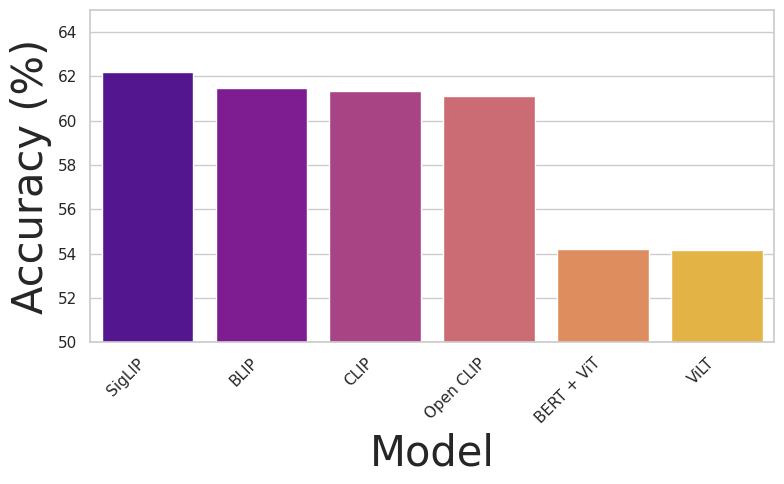

In [6]:
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Plot VQA Accuracy
ax = sns.barplot(data=df.sort_values('VQA Acc.', ascending=False), 
                 x='Model', 
                 y='VQA Acc.', 
                 palette='plasma')

# ax.set_title('VQA Task: Model Accuracy Comparison', fontsize=14)
ax.set_xlabel('Model', fontsize=30)
ax.set_ylabel('Accuracy (%)', fontsize=)
ax.set_ylim(50, 65) # Zoom in on the relevant score range

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('vqa_comparative_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

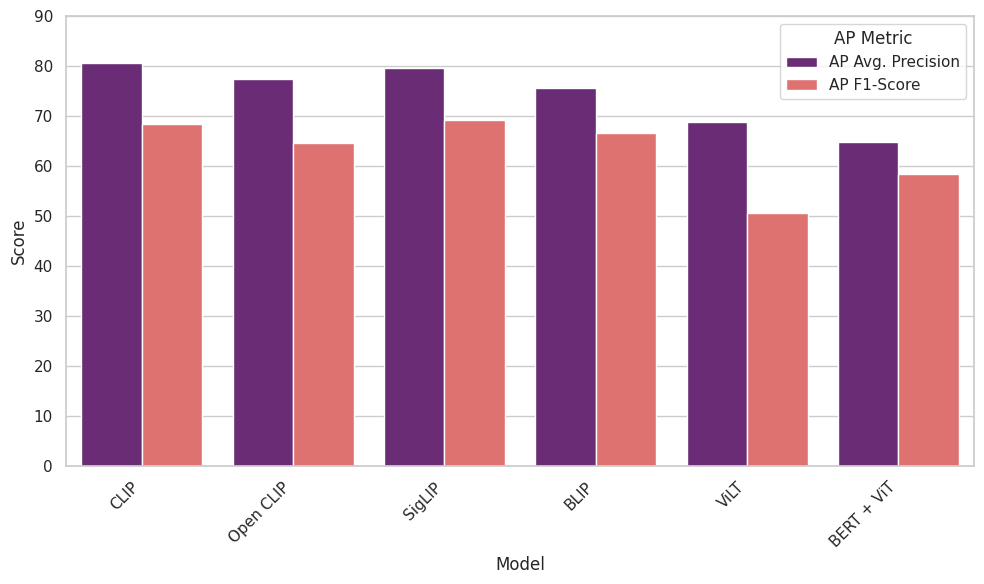

In [8]:
# Melt the DataFrame for AP metrics only
df_ap = df.melt(id_vars='Model', 
                value_vars=['AP Avg. Precision', 'AP F1-Score'],
                var_name='AP Metric', 
                value_name='Score')

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Plot AP Metrics
ax = sns.barplot(data=df_ap, x='Model', y='Score', hue='AP Metric', palette='magma')

# ax.set_title('AP Task: Model Performance Comparison', fontsize=14)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 90)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('ap_comparative_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# Create the DataFrame from per answer type data
data_vqa_types = {
    'Model': ['CLIP', 'Open CLIP', 'SigLIP', 'BLIP', 'ViLT', 'BERT + ViT'],
    'other': [47.05, 46.7, 47.98, 46.2, 36.81, 37.44],
    'unans.': [96.76, 97.55, 97.35, 96.89, 96.71, 97.76],
    'yes/no': [66.01, 61.24, 68.65, 79.49, 59.83, 45.34],
    'number': [29.05, 29.52, 26.35, 33.33, 22.06, 21.59]
}
df_vqa = pd.DataFrame(data_vqa_types)

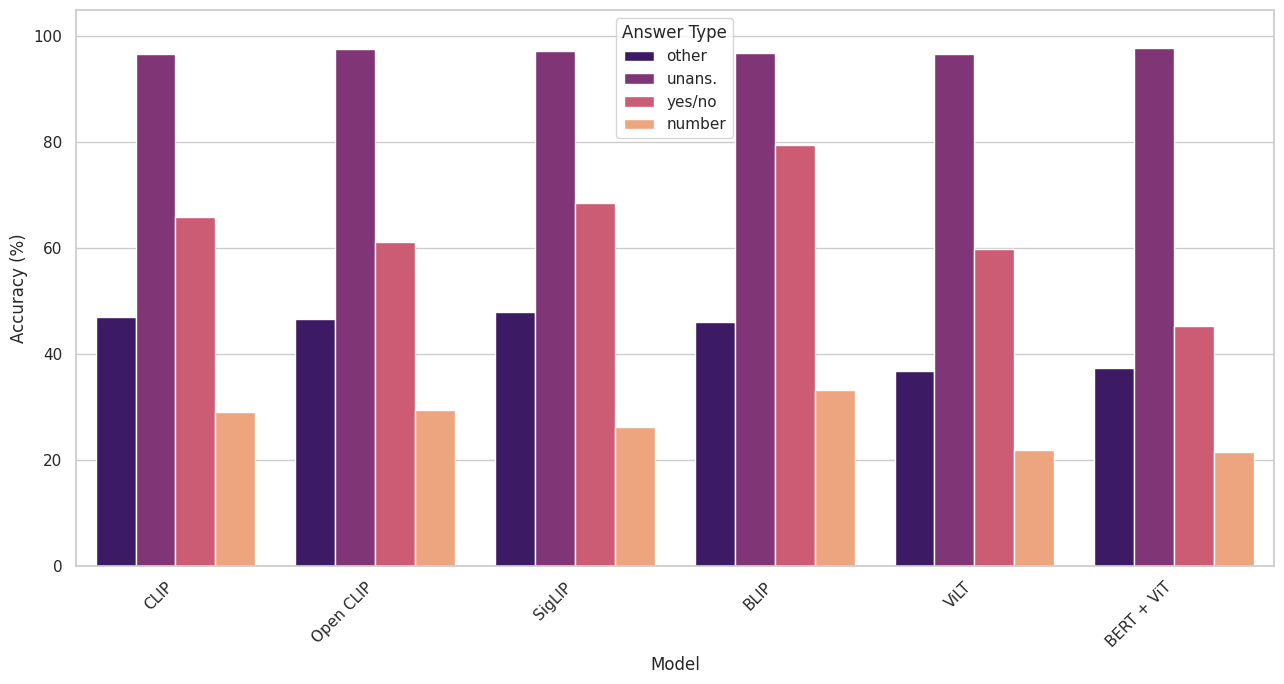

In [10]:
# "Melt" the DataFrame to a long format, which is ideal for plotting
df_vqa_melted = df_vqa.melt(id_vars='Model', var_name='Answer Type', value_name='Accuracy')

# Create the plot
plt.figure(figsize=(13, 7))
sns.set_theme(style="whitegrid")

# Draw the bar plot with models on the x-axis and answer types as colors
ax = sns.barplot(data=df_vqa_melted, x='Model', y='Accuracy', hue='Answer Type', palette='magma')

# Add titles and labels for clarity
# ax.set_title('VQA Accuracies Per Answer Type', fontsize=16)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim(0, 105) # Set y-axis to go up to 100

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')
plt.legend(title='Answer Type')
plt.tight_layout()
plt.savefig('answer_type_comp_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
data = {
    'Model': ['SigLIP', 'BLIP', 'CLIP'],
    'VQA Acc (test-dev)': [62.21, 61.5, 61.36],
    'VQA Acc (test-std)': [61.35, 60.83, 60.44],
    'AP Avg. Precision (test-dev)': [79.58, 75.64, 80.53],
    'AP Avg. Precision (test-std)': [78.82, 76.47, 79.05],
    'AP F1-Score (test-dev)': [69.14, 66.53, 68.37],
    'AP F1-Score (test-std)': [68.12, 66.39, 67.63]
}

# Create the DataFrame
df = pd.DataFrame(data)

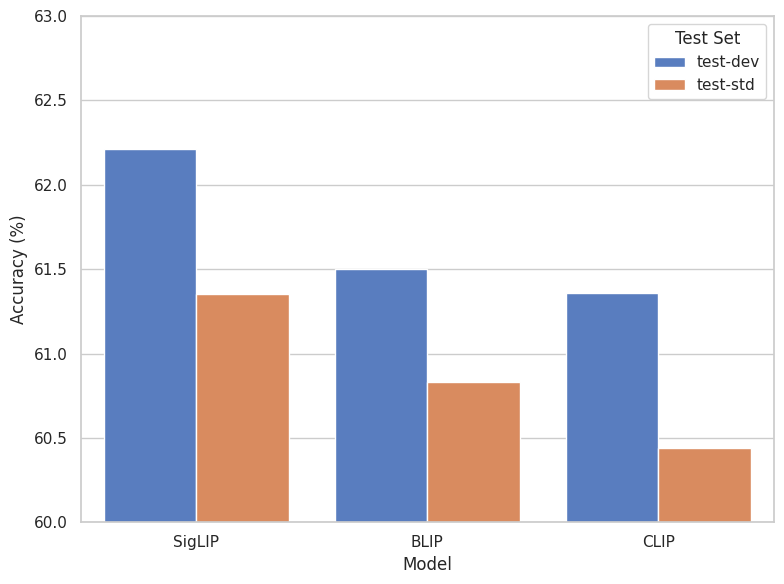

In [17]:
# Prepare the data for VQA plotting
df_vqa = df.melt(id_vars='Model',
                 value_vars=['VQA Acc (test-dev)', 'VQA Acc (test-std)'],
                 var_name='Metric',
                 value_name='Accuracy')
# Extract the test set type for the legend
df_vqa['Test Set'] = df_vqa['Metric'].apply(lambda x: 'test-dev' if 'dev' in x else 'test-std')

# Plotting
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(data=df_vqa, x='Model', y='Accuracy', hue='Test Set', palette='muted')

# ax.set_title('VQA Accuracy: test-dev vs. test-std', fontsize=16)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim(60, 63) # Zoom in to see the small differences clearly
plt.tight_layout()
plt.savefig('cand_vqa_accuracies.png', dpi=300, bbox_inches='tight')
plt.show()

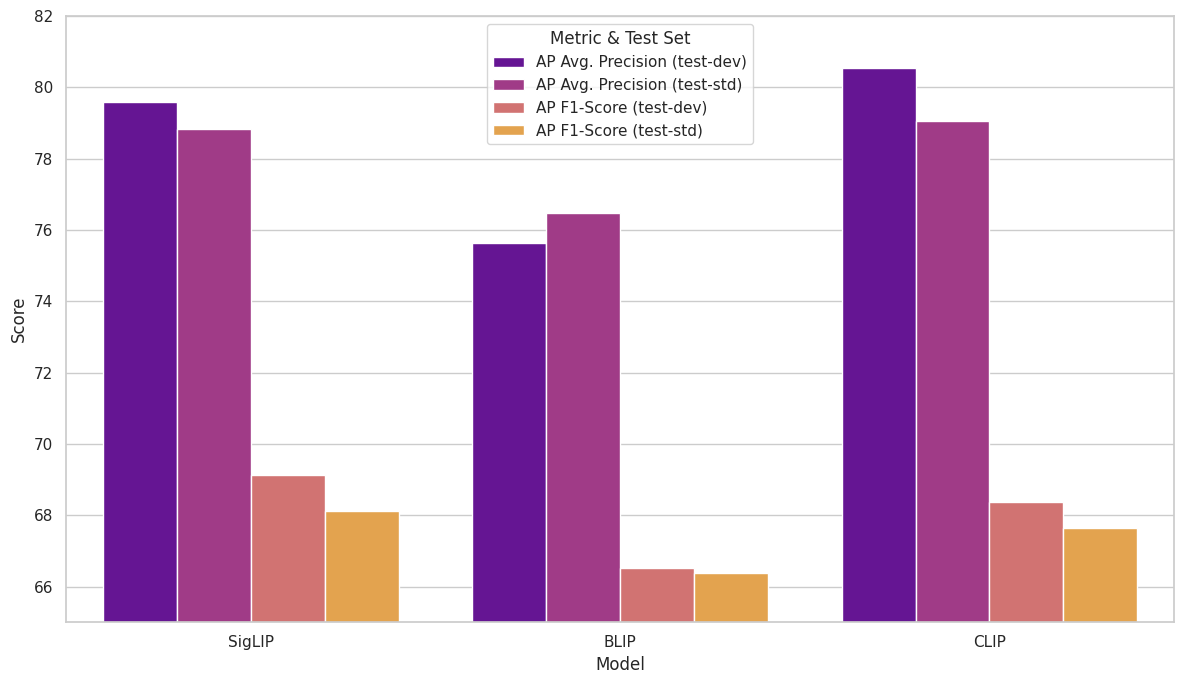

In [18]:
# Set up the initial DataFrame
data = {
    'Model': ['SigLIP', 'BLIP', 'CLIP'],
    'AP Avg. Precision (test-dev)': [79.58, 75.64, 80.53],
    'AP F1-Score (test-dev)': [69.14, 66.53, 68.37],
    'AP Avg. Precision (test-std)': [78.82, 76.47, 79.05],
    'AP F1-Score (test-std)': [68.12, 66.39, 67.63]
}
df_ap = pd.DataFrame(data)

# "Melt" the DataFrame to combine all AP metrics into a long format
# This is the key step to prepare for grouped plotting
df_ap_melted = df_ap.melt(
    id_vars='Model',
    value_vars=[
        'AP Avg. Precision (test-dev)', 'AP Avg. Precision (test-std)',
        'AP F1-Score (test-dev)', 'AP F1-Score (test-std)'
    ],
    var_name='Metric',
    value_name='Score'
)

# --- Plotting the Combined Chart ---
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Create the bar plot with 'Model' on the x-axis and the combined 'Metric' as the hue
ax = sns.barplot(data=df_ap_melted, x='Model', y='Score', hue='Metric', palette='plasma')

# Add titles and labels for clarity
# ax.set_title('Combined AP Performance: Avg. Precision & F1-Score', fontsize=16)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(65, 82) # Adjust y-axis to better highlight the differences

# Improve the legend and layout
plt.legend(title='Metric & Test Set')
plt.tight_layout()
plt.savefig('cand_ap_performance.png', dpi=300, bbox_inches='tight')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/tmp/ipykernel_36/2727001347.py:39: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.96])


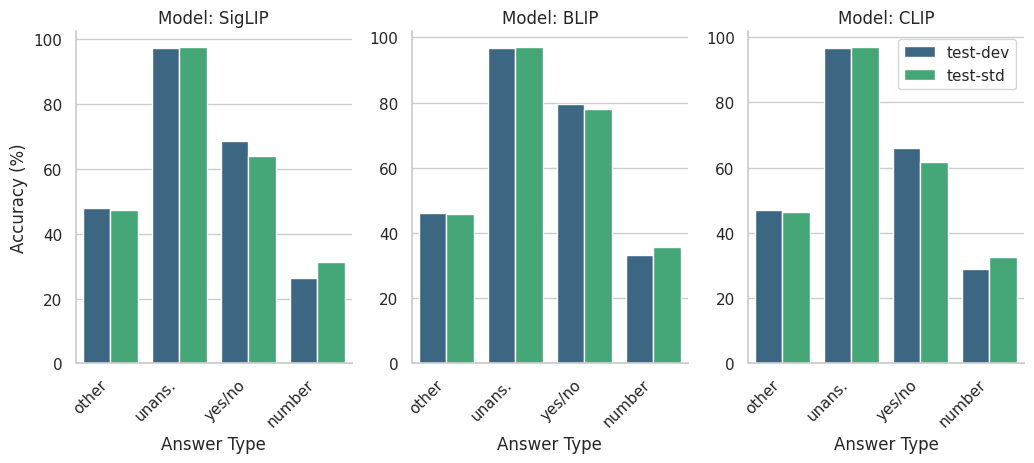

In [41]:
# We will use the same data setup from the previous step
data = {
    'Model': ['SigLIP', 'BLIP', 'CLIP'],
    'other_dev': [47.98, 46.2, 47.05], 'other_std': [47.39, 45.85, 46.41],
    'unans._dev': [97.35, 96.89, 96.76], 'unans._std': [97.6, 97.01, 96.95],
    'yes/no_dev': [68.65, 79.49, 66.01], 'yes/no_std': [64.15, 78.02, 61.83],
    'number_dev': [26.35, 33.33, 29.05], 'number_std': [31.22, 35.61, 32.6]
}
df = pd.DataFrame(data)

# "Melt" the DataFrame into a long format
df_melted = df.melt(id_vars='Model', var_name='Metric', value_name='Accuracy')

# Create separate columns for 'Answer Type' and 'Test Set'
df_melted['Answer Type'] = df_melted['Metric'].apply(lambda x: x.split('_')[0])
df_melted['Test Set'] = df_melted['Metric'].apply(lambda x: 'test-dev' if 'dev' in x else 'test-std')

# --- Create the Faceted Plot with Models as Subplots ---
g = sns.catplot(
    data=df_melted,
    x='Answer Type',    # Answer types on the x-axis of each subplot
    y='Accuracy',       # Accuracy on the y-axis
    hue='Test Set',     # Bars colored by test set (dev vs. std)
    col='Model',        # THIS CREATES A SUBPLOT FOR EACH MODEL
    kind='bar',
    sharey=False,       # Let each subplot have its own y-axis scale
    palette='viridis',
    height=5,
    aspect=0.7,
    legend=False
)

# Add a main title and format the plot
# g.fig.suptitle("Model Performance Profile by Answer Type", y=1.03, fontsize=16)
plt.legend(loc='upper right')
g.set_xticklabels(rotation=45, ha='right')
g.set_axis_labels("Answer Type", "Accuracy (%)")
g.set_titles("Model: {col_name}") # Customize subplot titles
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('cand_vqa_per_anstype_performance.png', dpi=300, bbox_inches='tight')
plt.show()

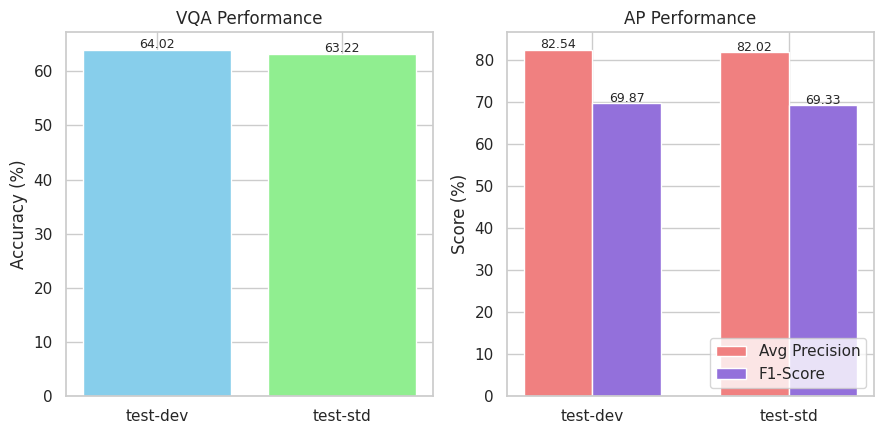

In [45]:
# Data from the table
tasks = ["test-dev", "test-std"]

# VQA performance (Accuracy)
vqa_acc = [64.02, 63.22]

# AP performance (Average Precision, F1-Score)
ap_avg_precision = [82.54, 82.02]
ap_f1_score = [69.87, 69.33]

# Create subplots with reduced width
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))

# --- Subplot 1: VQA performance ---
axes[0].bar(tasks, vqa_acc, color=["skyblue", "lightgreen"])
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("VQA Performance")
for i, val in enumerate(vqa_acc):
    axes[0].text(i, val + 0.3, f"{val:.2f}", ha="center", fontsize=9)

# --- Subplot 2: AP performance ---
x = np.arange(len(tasks))
width = 0.35

axes[1].bar(x - width/2, ap_avg_precision, width, label="Avg Precision", color="lightcoral")
axes[1].bar(x + width/2, ap_f1_score, width, label="F1-Score", color="mediumpurple")

axes[1].set_xticks(x)
axes[1].set_xticklabels(tasks)
axes[1].set_ylabel("Score (%)")
axes[1].set_title("AP Performance")
axes[1].legend()

for i, val in enumerate(ap_avg_precision):
    axes[1].text(i - width/2, val + 0.3, f"{val:.2f}", ha="center", fontsize=9)
for i, val in enumerate(ap_f1_score):
    axes[1].text(i + width/2, val + 0.3, f"{val:.2f}", ha="center", fontsize=9)

plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('ensemble_performance.png', dpi=300, bbox_inches='tight')
plt.show()

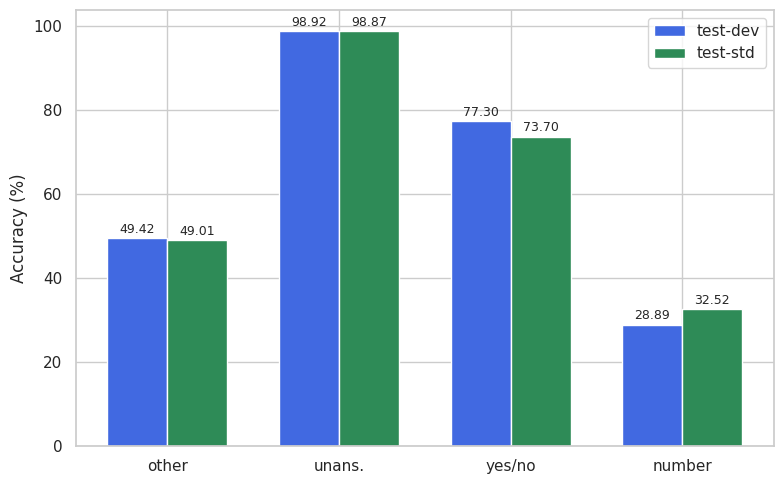

In [54]:
# Data from the table
categories = ["other", "unans.", "yes/no", "number"]

# Test-dev and test-std accuracies
test_dev = [49.42, 98.92, 77.3, 28.89]
test_std = [49.01, 98.87, 73.7, 32.52]

x = np.arange(len(categories))  # the label locations
width = 0.35  # bar width

# Plot grouped bar chart
fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, test_dev, width, label="test-dev", color="royalblue")
rects2 = ax.bar(x + width/2, test_std, width, label="test-std", color="seagreen")

# Labels and title
ax.set_ylabel("Accuracy (%)")
# ax.set_title("VQA Accuracy per Answer Type (Ensemble Model)")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

# Add value labels
for rect in rects1:
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2., height + 0.5,
            f'{height:.2f}', ha='center', va='bottom', fontsize=9)

for rect in rects2:
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2., height + 0.5,
            f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('ensemble_per_anstype_performance.png', dpi=300, bbox_inches='tight')
plt.show()


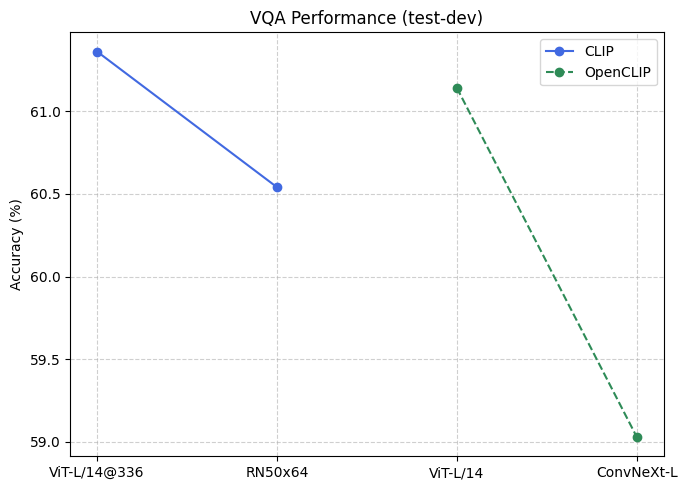

In [6]:
# Backbones
clip_backbones = ["ViT-L/14@336", "RN50x64"]
openclip_backbones = ["ViT-L/14", "ConvNeXt-L"]

# Data from table
vqa_acc_clip = [61.36, 60.54]
vqa_acc_openclip = [61.14, 59.03]

ap_avg_precision_clip = [80.53, 78.99]
ap_f1_clip = [68.37, 69.32]

ap_avg_precision_openclip = [77.34, 77.64]
ap_f1_openclip = [64.61, 67.42]

# --- Plot 1: VQA Accuracy ---
plt.figure(figsize=(7, 5))
plt.plot(clip_backbones, vqa_acc_clip, marker="o", linestyle="-", color="royalblue", label="CLIP")
plt.plot(openclip_backbones, vqa_acc_openclip, marker="o", linestyle="--", color="seagreen", label="OpenCLIP")

plt.ylabel("Accuracy (%)")
plt.title("VQA Performance (test-dev)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig('dualencoder_vqa_ablation.png', dpi=300, bbox_inches='tight')
plt.show()

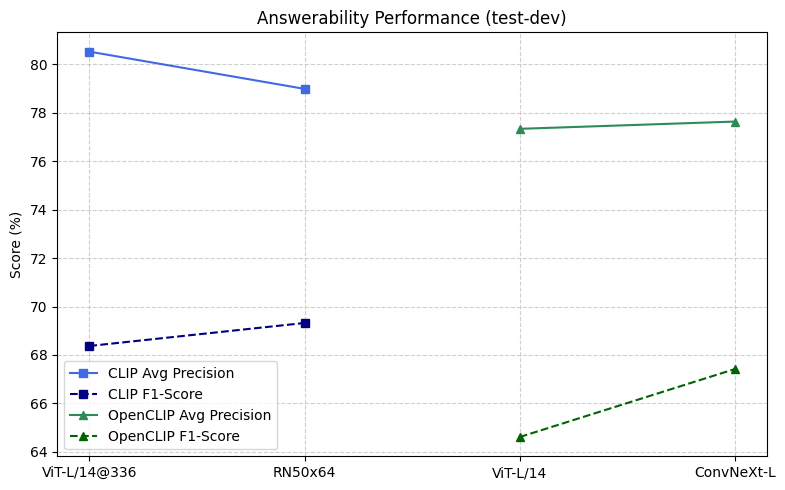

In [7]:
# --- Plot 2: Answerability (AP Performance) ---
plt.figure(figsize=(8, 5))
# CLIP
plt.plot(clip_backbones, ap_avg_precision_clip, marker="s", linestyle="-", color="royalblue", label="CLIP Avg Precision")
plt.plot(clip_backbones, ap_f1_clip, marker="s", linestyle="--", color="navy", label="CLIP F1-Score")
# OpenCLIP
plt.plot(openclip_backbones, ap_avg_precision_openclip, marker="^", linestyle="-", color="seagreen", label="OpenCLIP Avg Precision")
plt.plot(openclip_backbones, ap_f1_openclip, marker="^", linestyle="--", color="darkgreen", label="OpenCLIP F1-Score")

plt.ylabel("Score (%)")
plt.title("Answerability Performance (test-dev)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig('dualencoder_ap_ablation.png', dpi=300, bbox_inches='tight')
plt.show()

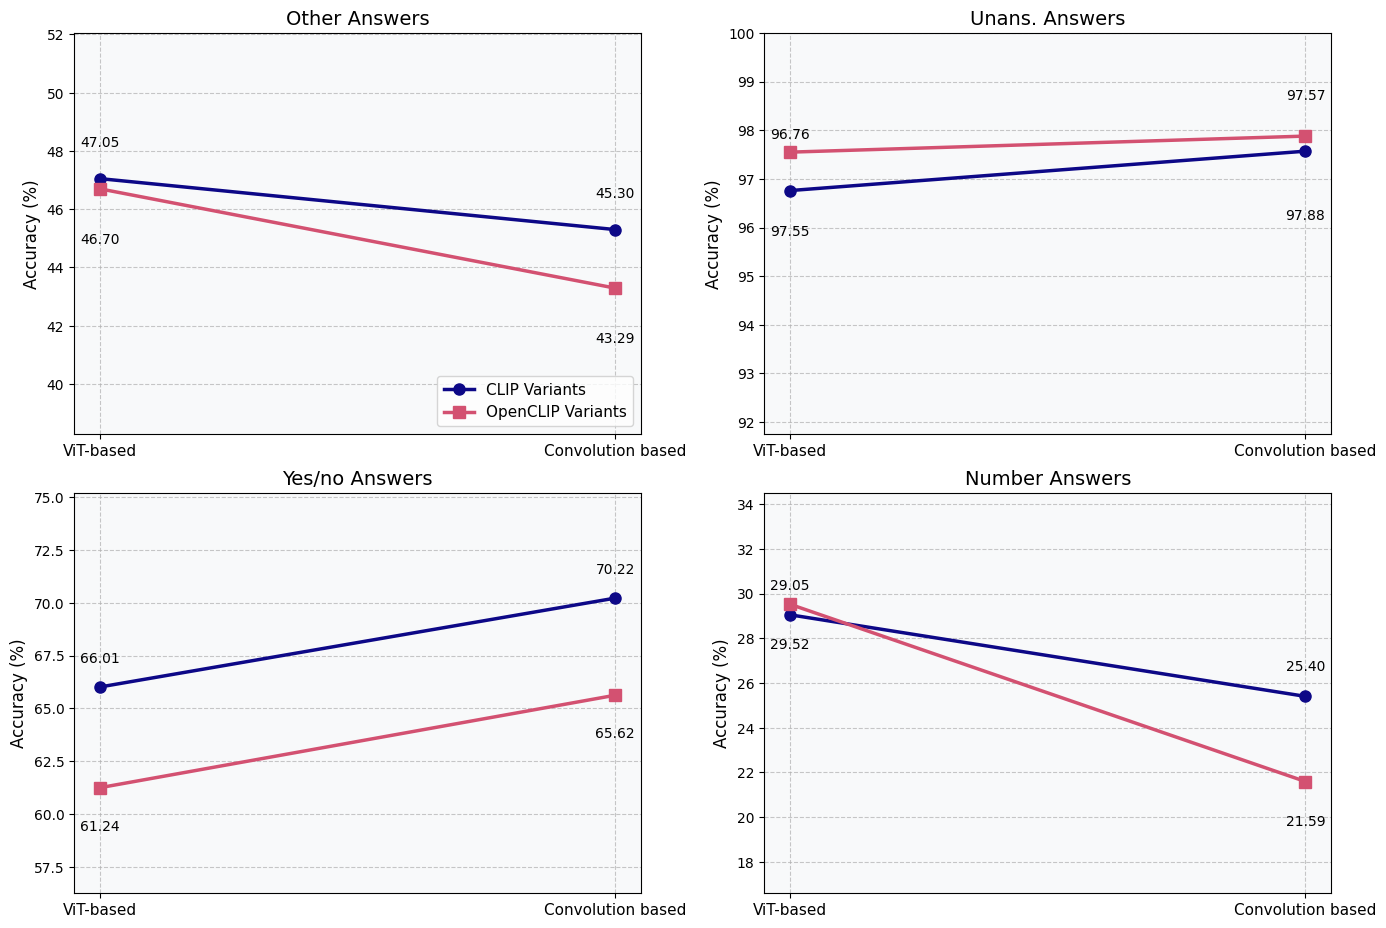

In [19]:
# Data from the table
models = [
    'CLIP (ViT-L/14@336px)',
    'CLIP (RN50x64)',
    'Open CLIP (ViT-L-14)',
    'Open CLIP (ConvNeXt-Large)'
]

answer_types = ['other', 'unans.', 'yes/no', 'number']

# Values from the table (test-dev)
data = np.array([
    [47.05, 96.76, 66.01, 29.05],  # CLIP (ViT-L/14@336px)
    [45.30, 97.57, 70.22, 25.40],  # CLIP (RN50x64)
    [46.70, 97.55, 61.24, 29.52],  # Open CLIP (ViT-L-14)
    [43.29, 97.88, 65.62, 21.59]   # Open CLIP (ConvNeXt-Large)
])

# Create a figure with subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
axes = [ax1, ax2, ax3, ax4]

# Use plasma colormap
plasma_cmap = plt.cm.plasma
colors = [plasma_cmap(i) for i in np.linspace(0, 0.8, len(models))]

# Plot each answer type in a separate subplot
for i, answer_type in enumerate(answer_types):
    ax = axes[i]
    
    # Plot CLIP variants
    ax.plot([1, 2], [data[0, i], data[1, i]], 
            marker='o', linestyle='-', linewidth=2.5, markersize=8,
            color=colors[0], label='CLIP Variants')
    
    # Plot OpenCLIP variants
    ax.plot([1, 2], [data[2, i], data[3, i]], 
            marker='s', linestyle='-', linewidth=2.5, markersize=8,
            color=colors[2], label='OpenCLIP Variants')
    
    # Add data labels
    ax.text(1, data[0, i] + 1, f'{data[0, i]:.2f}', 
            ha='center', va='bottom', fontsize=10)
    ax.text(2, data[1, i] + 1, f'{data[1, i]:.2f}', 
            ha='center', va='bottom', fontsize=10)
    ax.text(1, data[2, i] - 1.5, f'{data[2, i]:.2f}', 
            ha='center', va='top', fontsize=10)
    ax.text(2, data[3, i] - 1.5, f'{data[3, i]:.2f}', 
            ha='center', va='top', fontsize=10)
    
    # Customize subplot
    ax.set_title(f'{answer_type.capitalize()} Answers', fontsize=14)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_xticks([1, 2])
    
    # Set different x-axis labels for each subplot
    if i == 0 or i == 2:
        ax.set_xticklabels(['ViT-based', 'Convolution based'], fontsize=11)
    else:
        ax.set_xticklabels(['ViT-based', 'Convolution based'], fontsize=11)
    
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_facecolor('#f8f9fa')
    
    # Set y-axis limits based on data range
    min_val = min(data[:, i]) - 5
    max_val = max(data[:, i]) + 5
    ax.set_ylim(max(0, min_val), min(100, max_val))
    
    # Add legend to the first subplot only
    if i == 0:
        ax.legend(loc='lower right', fontsize=11)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.savefig('dualencoder_vqa_anstype_ablation.png', dpi=300, bbox_inches='tight')
plt.show()

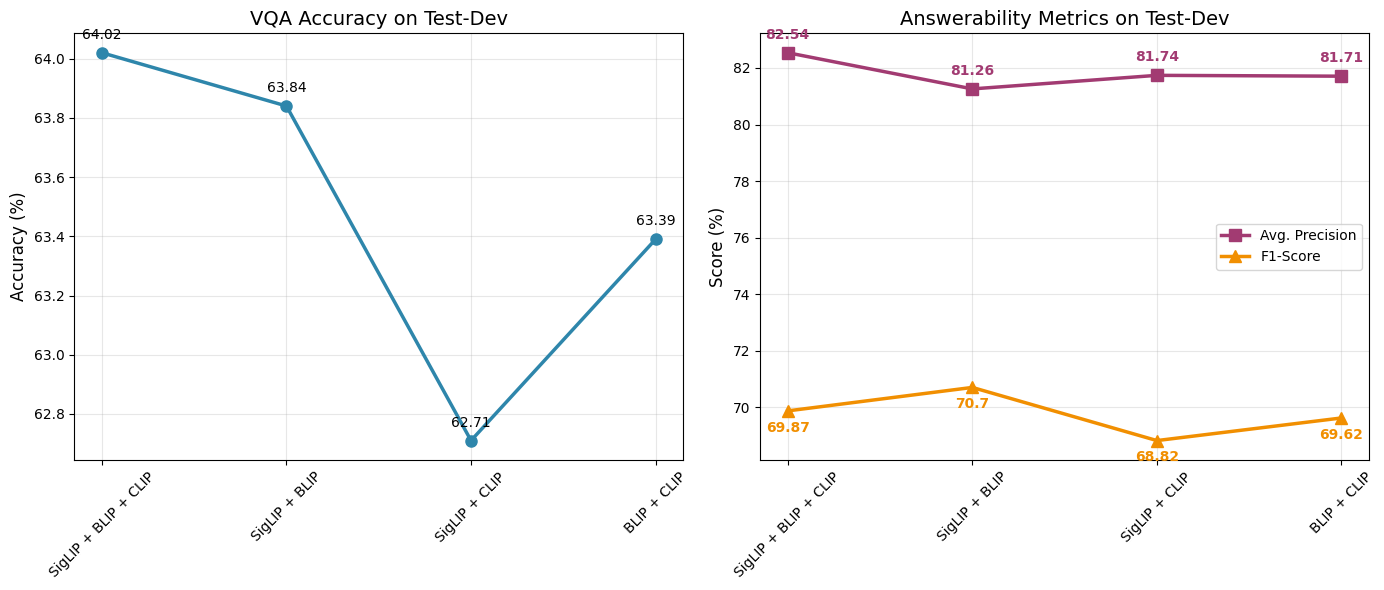

In [4]:
# Data from the table
models = [
    'SigLIP + BLIP + CLIP',
    'SigLIP + BLIP',
    'SigLIP + CLIP',
    'BLIP + CLIP'
]

vqa_accuracy = [64.02, 63.84, 62.71, 63.39]
avg_precision = [82.54, 81.26, 81.74, 81.71]
f1_score = [69.87, 70.7, 68.82, 69.62]

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# VQA Accuracy plot
ax1.plot(models, vqa_accuracy, marker='o', linewidth=2.5, markersize=8, color='#2E86AB')
ax1.set_title('VQA Accuracy on Test-Dev', fontsize=14)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Add value labels on points
for i, v in enumerate(vqa_accuracy):
    ax1.annotate(f'{v}', (i, v), textcoords="offset points", xytext=(0,10), ha='center')

# Answerability metrics plot
ax2.plot(models, avg_precision, marker='s', linewidth=2.5, markersize=8, color='#A23B72', label='Avg. Precision')
ax2.plot(models, f1_score, marker='^', linewidth=2.5, markersize=8, color='#F18F01', label='F1-Score')
ax2.set_title('Answerability Metrics on Test-Dev', fontsize=14)
ax2.set_ylabel('Score (%)', fontsize=12)
ax2.legend(loc='right')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# Add value labels on points
for i, (v1, v2) in enumerate(zip(avg_precision, f1_score)):
    ax2.annotate(f'{v1}', (i, v1), textcoords="offset points", 
                 xytext=(0,10), ha='center', fontweight='bold', color='#A23B72')
    ax2.annotate(f'{v2}', (i, v2), textcoords="offset points", 
                 xytext=(0,-15), ha='center', fontweight='bold', color='#F18F01')

# Adjust layout and display
plt.tight_layout()
plt.savefig('ensemble_ablation.png', dpi=300, bbox_inches='tight')
plt.show()

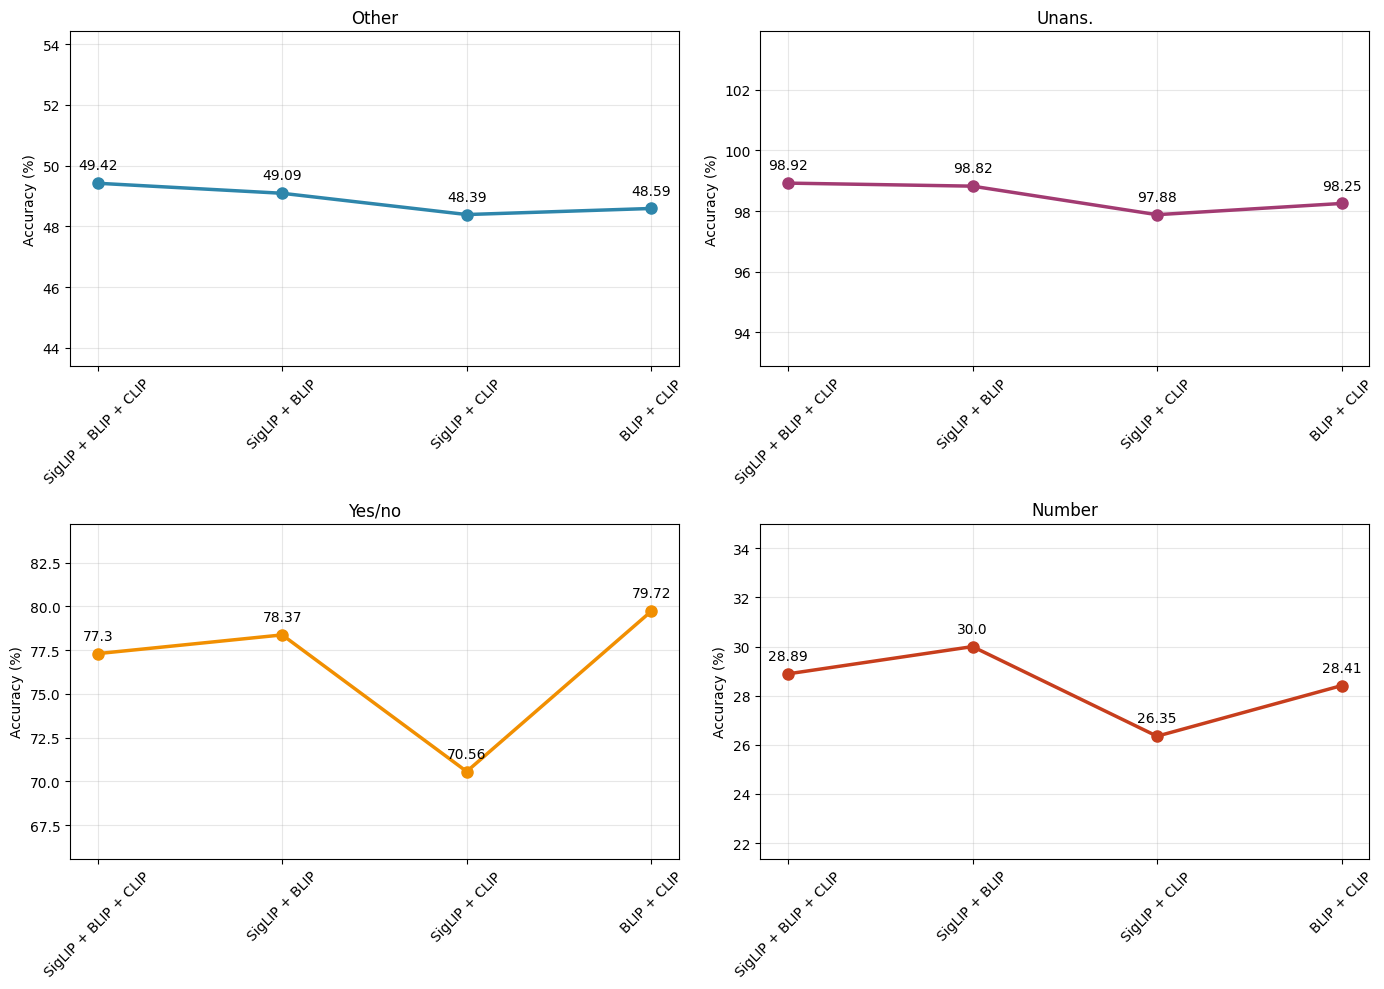

In [9]:
# Data from the table
models = [
    'SigLIP + BLIP + CLIP',
    'SigLIP + BLIP',
    'SigLIP + CLIP',
    'BLIP + CLIP'
]

answer_types = ['other', 'unans.', 'yes/no', 'number']
accuracies = [
    [49.42, 98.92, 77.3, 28.89],    # SigLIP + BLIP + CLIP
    [49.09, 98.82, 78.37, 30.0],    # SigLIP + BLIP
    [48.39, 97.88, 70.56, 26.35],   # SigLIP + CLIP
    [48.59, 98.25, 79.72, 28.41]    # BLIP + CLIP
]

# Convert to numpy array for easier manipulation
accuracies = np.array(accuracies)

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Colors for each answer type
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

# Plot each answer type in a separate subplot
for i, answer_type in enumerate(answer_types):
    row, col = i // 2, i % 2
    ax = axes[row, col]
    
    # Plot the data
    ax.plot(models, accuracies[:, i], marker='o', linewidth=2.5, 
            markersize=8, color=colors[i], label=answer_type)
    
    # Customize the subplot
    ax.set_title(f'{answer_type.capitalize()}', fontsize=12)
    ax.set_ylabel('Accuracy (%)', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    
    # Add value labels on points
    for j, v in enumerate(accuracies[:, i]):
        ax.annotate(f'{v}', (j, v), textcoords="offset points", xytext=(0,10), ha='center')
    
    # Set y-axis limits based on data range for better visualization
    min_val = min(accuracies[:, i])
    max_val = max(accuracies[:, i])
    ax.set_ylim(min_val - 5, max_val + 5)

# Adjust layout
plt.tight_layout()
plt.savefig('ensemble_per_anstype_ablation.png', dpi=300, bbox_inches='tight')
plt.show()